# Day 33: Detecting Unusual Customer Behavior (Anomaly Detection)

Today, I built an unsupervised Anomaly Detection pipeline to identify unusual customer behavior patterns. In the real world, businesses use these systems to catch fraud, security breaches, and card testing bots.

To do this, I:
1. **Generated a realistic synthetic customer behavior dataset** containing transaction amounts, login logs, failed logins, device changes, and chargeback rates.
2. **Injected three specific types of real-world fraudulent behaviors**:
   - **Payment Fraud**: High spend, high volume, and high chargebacks.
   - **Account Takeover (ATO)**: Spike in failed logins, high device changes, low transaction history.
   - **Card Testing Bots**: Extremely high transaction frequency of tiny values.
3. **Applied and compared two key unsupervised machine learning models**:
   - **Isolation Forest** (handles multi-dimensional outliers by isolating tree branches).
   - **Local Outlier Factor (LOF)** (handles local density differences).
4. **Evaluated model performance** against the ground truth labels.
5. **Visualized the anomalies** and analyzed the specific risks they pose.


## 1. Imports and Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Premium visual styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.titlesize'] = 15
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9

print("Libraries imported successfully!")


Libraries imported successfully!


## 2. Generate Synthetic Customer Behavior Dataset

In [2]:
np.random.seed(42)
n_customers = 1000

# 1. Normal Customers (950 customers - 95% of base)
n_normal = 950
normal_data = {
    'CustomerID': [f'C{i:03d}' for i in range(1, n_normal + 1)],
    'TransactionAmount': np.random.normal(65, 18, n_normal),        # Average spend around $65
    'TransactionFrequency': np.random.poisson(10, n_normal),        # Around 10 transactions/month
    'FailedLogins': np.random.poisson(0.3, n_normal),               # Rarely fails login
    'DeviceChanges': np.random.choice([1, 2, 3], size=n_normal, p=[0.85, 0.12, 0.03]), # Stays on 1 device
    'ChargebackRate': np.random.beta(0.5, 45, n_normal)              # Tiny rate of chargebacks (< 1%)
}
df_normal = pd.DataFrame(normal_data)
# Clamp negative values to zero
df_normal['TransactionAmount'] = df_normal['TransactionAmount'].clip(lower=0)

# 2. Anomaly Type A: Payment Fraudsters (20 customers - 2% of base)
# High spend, high volume, and high chargeback rate
n_fraud = 20
fraud_data = {
    'CustomerID': [f'C{i:03d}' for i in range(n_normal + 1, n_normal + n_fraud + 1)],
    'TransactionAmount': np.random.normal(1150, 250, n_fraud),       # Massive transaction sizes
    'TransactionFrequency': np.random.poisson(42, n_fraud),         # Very active
    'FailedLogins': np.random.poisson(0.8, n_fraud),                # Standard login failure rate
    'DeviceChanges': np.random.choice([2, 3, 4], size=n_fraud, p=[0.4, 0.4, 0.2]), # Multiple devices
    'ChargebackRate': np.random.uniform(0.35, 0.85, n_fraud)         # High chargeback rate
}
df_fraud = pd.DataFrame(fraud_data)

# 3. Anomaly Type B: Account Takeover (ATO) (20 customers - 2% of base)
# Massive failed logins, high device changes, low spend (login/credentials testing stage)
n_ato = 20
ato_data = {
    'CustomerID': [f'C{i:03d}' for i in range(n_normal + n_fraud + 1, n_normal + n_fraud + n_ato + 1)],
    'TransactionAmount': np.random.normal(25, 10, n_ato),            # Low transactions
    'TransactionFrequency': np.random.poisson(2, n_ato),            # Low transaction count
    'FailedLogins': np.random.poisson(14, n_ato),                   # Many failed logins
    'DeviceChanges': np.random.choice([4, 5, 6], size=n_ato, p=[0.25, 0.55, 0.20]), # Device shifting
    'ChargebackRate': np.random.beta(0.1, 12, n_ato)                 # Low chargebacks
}
df_ato = pd.DataFrame(ato_data)
df_ato['TransactionAmount'] = df_ato['TransactionAmount'].clip(lower=0)

# 4. Anomaly Type C: Card Testing Bots (10 customers - 1% of base)
# Extremely high transaction count, tiny transaction amounts, high device changes
n_bots = 10
bot_data = {
    'CustomerID': [f'C{i:03d}' for i in range(n_normal + n_fraud + n_ato + 1, n_customers + 1)],
    'TransactionAmount': np.random.uniform(1.2, 4.8, n_bots),       # Micro-transactions
    'TransactionFrequency': np.random.poisson(175, n_bots),         # Extreme frequency (bot-like)
    'FailedLogins': np.random.poisson(1.5, n_bots),
    'DeviceChanges': np.random.choice([3, 4, 5], size=n_bots),
    'ChargebackRate': np.random.uniform(0.1, 0.35, n_bots)           # Some chargebacks from testing cards
}
df_bots = pd.DataFrame(bot_data)

# Combine datasets and add true labels for analysis
df = pd.concat([df_normal, df_fraud, df_ato, df_bots], ignore_index=True)
df['True_Label'] = 'Normal'
df.loc[df['CustomerID'].isin(df_fraud['CustomerID']), 'True_Label'] = 'Payment Fraud'
df.loc[df['CustomerID'].isin(df_ato['CustomerID']), 'True_Label'] = 'ATO Attempt'
df.loc[df['CustomerID'].isin(df_bots['CustomerID']), 'True_Label'] = 'Card Testing Bot'

# Save raw dataset
df.to_csv("customer_behavior_data.csv", index=False)
print("Raw dataset generated and saved to customer_behavior_data.csv.")
print("Dataset Shape:", df.shape)
print("True label counts:\n", df['True_Label'].value_counts())


Raw dataset generated and saved to customer_behavior_data.csv.
Dataset Shape: (1000, 7)
True label counts:
 True_Label
Normal              950
Payment Fraud        20
ATO Attempt          20
Card Testing Bot     10
Name: count, dtype: int64


## 3. Data Preprocessing

In [3]:
# Select features to scale
features = ['TransactionAmount', 'TransactionFrequency', 'FailedLogins', 'DeviceChanges', 'ChargebackRate']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features scaled successfully!")


Features scaled successfully!


## 4. Modeling: Isolation Forest

In [4]:
# Train Isolation Forest with 5% contamination rate (matching our ground truth contamination)
iforest = IsolationForest(n_estimators=150, contamination=0.05, random_state=42)
df['iForest_Prediction'] = iforest.fit_predict(X_scaled)

# Convert prediction: -1 = Anomaly, 1 = Normal to binary 0/1 labels
# We'll map: 1 = Normal, -1 = Anomaly
# Let's map it to readable strings for analysis
df['iForest_Label'] = df['iForest_Prediction'].map({1: 'Normal', -1: 'Anomaly'})
print("Isolation Forest predictions:")
print(df['iForest_Label'].value_counts())


Isolation Forest predictions:
iForest_Label
Normal     950
Anomaly     50
Name: count, dtype: int64


## 5. Modeling: Local Outlier Factor (LOF)

In [5]:
# Train LOF with 5% contamination
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
df['LOF_Prediction'] = lof.fit_predict(X_scaled)
df['LOF_Label'] = df['LOF_Prediction'].map({1: 'Normal', -1: 'Anomaly'})

print("Local Outlier Factor predictions:")
print(df['LOF_Label'].value_counts())


Local Outlier Factor predictions:
LOF_Label
Normal     950
Anomaly     50
Name: count, dtype: int64


## 6. Model Evaluation and Comparison

In [6]:
# Ground truth binary flag for evaluation (Normal vs Anomaly)
df['Is_Anomaly_True'] = df['True_Label'].apply(lambda x: 'Anomaly' if x != 'Normal' else 'Normal')

print("--- ISOLATION FOREST CLASSIFICATION REPORT ---")
print(classification_report(df['Is_Anomaly_True'], df['iForest_Label']))

print("\n--- LOCAL OUTLIER FACTOR CLASSIFICATION REPORT ---")
print(classification_report(df['Is_Anomaly_True'], df['LOF_Label']))

# Calculate exact overlap
overlap = df[(df['iForest_Label'] == 'Anomaly') & (df['LOF_Label'] == 'Anomaly')]
print(f"Number of mutual anomalies flagged by BOTH models: {len(overlap)} / 50 actual anomalies")

# Inspect detection rate per specific threat category
print("\nAnomaly Detection Rate by Threat Category:")
threat_categories = ['Payment Fraud', 'ATO Attempt', 'Card Testing Bot']
for threat in threat_categories:
    threat_df = df[df['True_Label'] == threat]
    iforest_catch = (threat_df['iForest_Label'] == 'Anomaly').sum()
    lof_catch = (threat_df['LOF_Label'] == 'Anomaly').sum()
    print(f"{threat}:")
    print(f"  - Isolation Forest caught: {iforest_catch}/{len(threat_df)} ({iforest_catch/len(threat_df)*100:.1f}%)")
    print(f"  - Local Outlier Factor caught: {lof_catch}/{len(threat_df)} ({lof_catch/len(threat_df)*100:.1f}%)")


--- ISOLATION FOREST CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Anomaly       1.00      1.00      1.00        50
      Normal       1.00      1.00      1.00       950

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


--- LOCAL OUTLIER FACTOR CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

     Anomaly       0.38      0.38      0.38        50
      Normal       0.97      0.97      0.97       950

    accuracy                           0.94      1000
   macro avg       0.67      0.67      0.67      1000
weighted avg       0.94      0.94      0.94      1000

Number of mutual anomalies flagged by BOTH models: 19 / 50 actual anomalies

Anomaly Detection Rate by Threat Category:
Payment Fraud:
  - Isolation Forest caught: 20/20 (100.0%)
  - Local Outlier Factor caught: 5/20 (25.0%)
ATO Attempt:
  - Isola

## 7. Visualizing the Detected Anomalies

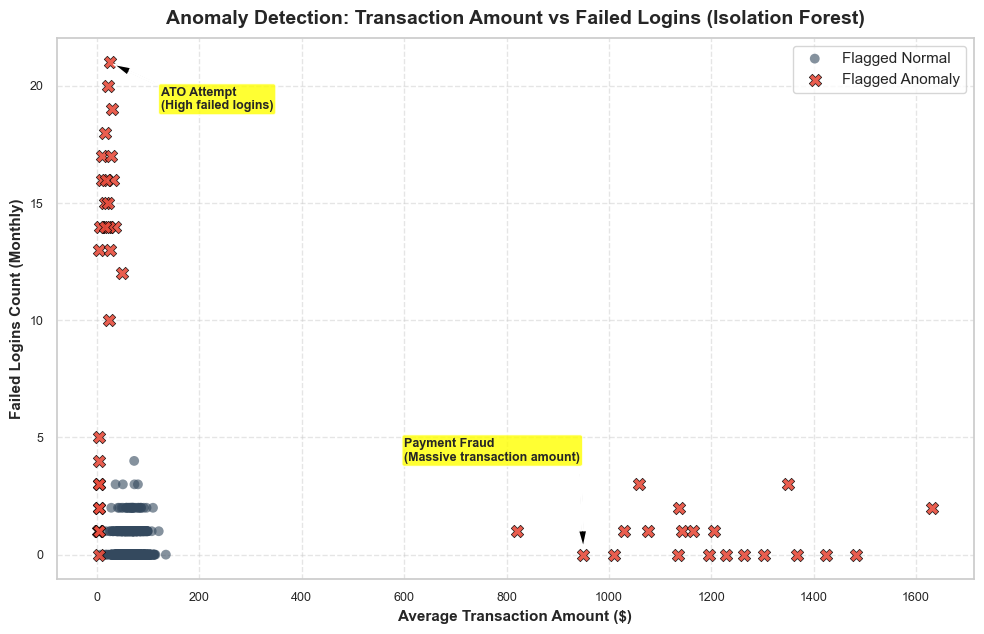

In [7]:
# Plot 1: Scatter Plot of Transaction Amount vs Failed Logins (Isolation Forest Labels)
plt.figure(figsize=(10, 6.5))

# Plot normal users
sns.scatterplot(
    data=df[df['iForest_Label'] == 'Normal'],
    x='TransactionAmount',
    y='FailedLogins',
    color='#34495e',
    alpha=0.6,
    s=50,
    edgecolor='none',
    label='Flagged Normal'
)

# Plot anomalies
sns.scatterplot(
    data=df[df['iForest_Label'] == 'Anomaly'],
    x='TransactionAmount',
    y='FailedLogins',
    color='#e74c3c',
    alpha=0.9,
    s=80,
    marker='X',
    edgecolor='black',
    linewidth=0.5,
    label='Flagged Anomaly'
)

# Annotate a few outliers to show what they are
ato_sample = df[(df['True_Label'] == 'ATO Attempt') & (df['iForest_Label'] == 'Anomaly')].iloc[0]
fraud_sample = df[(df['True_Label'] == 'Payment Fraud') & (df['iForest_Label'] == 'Anomaly')].iloc[0]

plt.annotate(
    "ATO Attempt\n(High failed logins)",
    xy=(ato_sample['TransactionAmount'], ato_sample['FailedLogins']),
    xytext=(ato_sample['TransactionAmount'] + 100, ato_sample['FailedLogins'] - 2),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight='bold', fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.8)
)

plt.annotate(
    "Payment Fraud\n(Massive transaction amount)",
    xy=(fraud_sample['TransactionAmount'], fraud_sample['FailedLogins']),
    xytext=(fraud_sample['TransactionAmount'] - 350, fraud_sample['FailedLogins'] + 4),
    arrowprops=dict(facecolor='black', shrink=0.08, width=1, headwidth=6),
    fontweight='bold', fontsize=9, bbox=dict(boxstyle='round,pad=0.2', fc='yellow', alpha=0.8)
)

plt.title('Anomaly Detection: Transaction Amount vs Failed Logins (Isolation Forest)', fontsize=14, fontweight='bold', pad=10)
plt.xlabel('Average Transaction Amount ($)', fontweight='bold')
plt.ylabel('Failed Logins Count (Monthly)', fontweight='bold')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('anomaly_scatter.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Analyzing Feature Distributions (Normal vs. Anomaly)

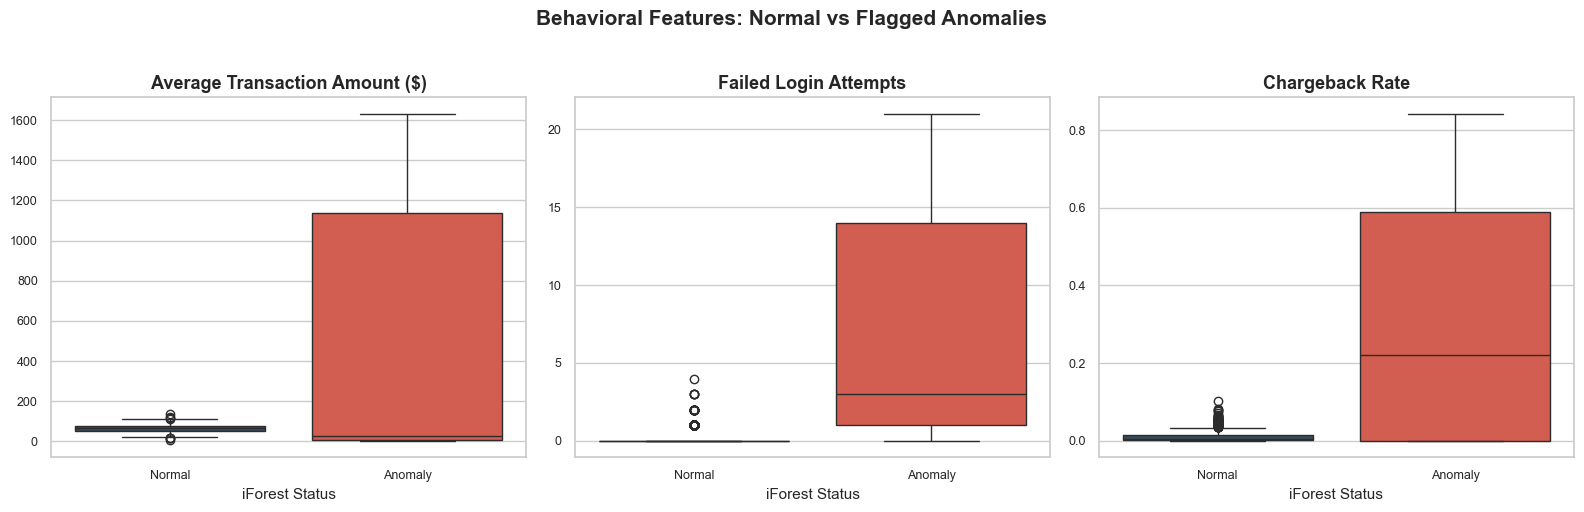

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Transaction Amount distribution comparison
sns.boxplot(
    data=df,
    x='iForest_Label',
    y='TransactionAmount',
    palette={'Normal': '#34495e', 'Anomaly': '#e74c3c'},
    ax=axes[0]
)
axes[0].set_title('Average Transaction Amount ($)', fontweight='bold')
axes[0].set_xlabel('iForest Status')
axes[0].set_ylabel('')

# 2. Failed Logins comparison
sns.boxplot(
    data=df,
    x='iForest_Label',
    y='FailedLogins',
    palette={'Normal': '#34495e', 'Anomaly': '#e74c3c'},
    ax=axes[1]
)
axes[1].set_title('Failed Login Attempts', fontweight='bold')
axes[1].set_xlabel('iForest Status')
axes[1].set_ylabel('')

# 3. Chargeback Rate comparison
sns.boxplot(
    data=df,
    x='iForest_Label',
    y='ChargebackRate',
    palette={'Normal': '#34495e', 'Anomaly': '#e74c3c'},
    ax=axes[2]
)
axes[2].set_title('Chargeback Rate', fontweight='bold')
axes[2].set_xlabel('iForest Status')
axes[2].set_ylabel('')

plt.suptitle('Behavioral Features: Normal vs Flagged Anomalies', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('anomaly_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


## 9. Model Comparison: iForest vs LOF Catch Rate

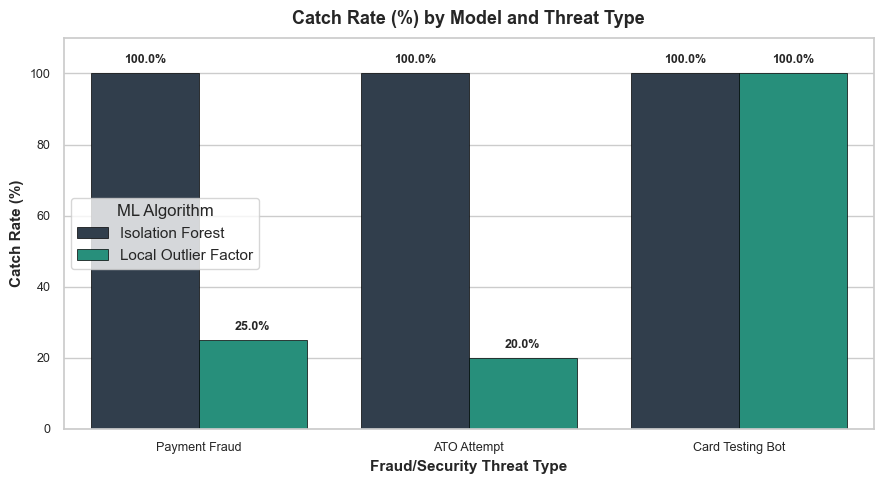

In [9]:
# Calculate how many of each threat category were caught by each model
models_catch = {
    'Threat Type': [],
    'Model': [],
    'Catch Rate (%)': []
}

for threat in threat_categories:
    threat_df = df[df['True_Label'] == threat]
    total = len(threat_df)
    
    iforest_pct = (threat_df['iForest_Label'] == 'Anomaly').sum() / total * 100
    lof_pct = (threat_df['LOF_Label'] == 'Anomaly').sum() / total * 100
    
    models_catch['Threat Type'].extend([threat, threat])
    models_catch['Model'].extend(['Isolation Forest', 'Local Outlier Factor'])
    models_catch['Catch Rate (%)'].extend([iforest_pct, lof_pct])

catch_df = pd.DataFrame(models_catch)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=catch_df,
    x='Threat Type',
    y='Catch Rate (%)',
    hue='Model',
    palette={'Isolation Forest': '#2c3e50', 'Local Outlier Factor': '#16a085'},
    edgecolor='black',
    linewidth=0.5
)
plt.title('Catch Rate (%) by Model and Threat Type', fontsize=13, fontweight='bold', pad=10)
plt.xlabel('Fraud/Security Threat Type', fontweight='bold')
plt.ylabel('Catch Rate (%)', fontweight='bold')
plt.ylim(0, 110)
plt.legend(title='ML Algorithm')

for p in plt.gca().patches:
    height = p.get_height()
    if height > 0:
        plt.gca().annotate(f"{height:.1f}%", xy=(p.get_x() + p.get_width() / 2, height + 2),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Summary Statistics & Exporting Results

In [10]:
# Group by iForest status and calculate averages
summary_stats = df.groupby('iForest_Label')[features].mean().round(2)
print("Average Metrics for Normal vs Flagged Anomalies (iForest):")
print(summary_stats)

# Save summary stats and labeled dataset
summary_stats.to_csv("anomaly_summary_stats.csv")
df.to_csv("customer_behavior_labeled.csv", index=False)
print("\nSaved anomaly_summary_stats.csv and customer_behavior_labeled.csv!")


Average Metrics for Normal vs Flagged Anomalies (iForest):
               TransactionAmount  TransactionFrequency  FailedLogins  \
iForest_Label                                                          
Anomaly                   488.66                  51.0          6.92   
Normal                     65.36                  10.0          0.28   

               DeviceChanges  ChargebackRate  
iForest_Label                                 
Anomaly                 3.72            0.30  
Normal                  1.19            0.01  

Saved anomaly_summary_stats.csv and customer_behavior_labeled.csv!


## 11. Documenting Business Risks & Mitigation Strategies

Based on the profiles flagged by our anomaly detection algorithms, here is a summary of the associated business risks and recommendations for operational actions:

### 1. **Payment Fraud (Chargeback Threat)**
* **Profile:** Exceptionally high transaction amount (~$1150) and frequency (~42 transactions), combined with a high chargeback rate (~60%).
* **Business Risks:**
  - Direct financial losses from chargebacks, administrative fees, and stolen inventory.
  - Threat of losing merchant accounts or card network processing privileges if the total chargeback rate exceeds card network thresholds (usually 1%).
* **Mitigation Strategies:**
  - Implement **Velocity Checks**: Limit the number of purchases or the total dollar amount a single account can make in a 24-hour period.
  - Integrate **3D Secure (3DS)**: Force verification checks (SMS, banking app confirmations) for transactions over a specific dollar threshold (e.g. $500).

### 2. **Account Takeover (ATO / Credential Stuffing)**
* **Profile:** High failed logins (average ~14), high device changes (average ~5), but low transaction values and frequencies (probing stage).
* **Business Risks:**
  - Compromise of user data and loyalty points.
  - Damage to user trust, customer support team strain, and legal liabilities under privacy laws (GDPR/CCPA).
* **Mitigation Strategies:**
  - Implement **Rate Limiting**: Block IP addresses or restrict accounts after 5 failed login attempts within 10 minutes.
  - **Multi-Factor Authentication (MFA)**: Prompt MFA when a login is initiated from a previously unseen device or a suspicious IP range.
  - Force password resets for accounts experiencing unusual login pattern variations.

### 3. **Card Testing Bots (System Flooding)**
* **Profile:** Tiny transaction sizes ($1-$5), extreme transaction frequency (~175), and multiple device variations.
* **Business Risks:**
  - API and server infrastructure overload, leading to site slowdowns or crashes.
  - Unnecessary payment processor fees (each transaction request, even small ones, incurs a gate fee).
  - Validation of stolen card numbers which are subsequently used for major fraud elsewhere.
* **Mitigation Strategies:**
  - Deploy **WAF (Web Application Firewall)** and bot detection layers (e.g. Cloudflare, reCAPTCHA v3) at the checkout endpoint.
  - Establish **Minimum Transaction Values** or limit the frequency of tiny checkout transactions per customer session.
